4


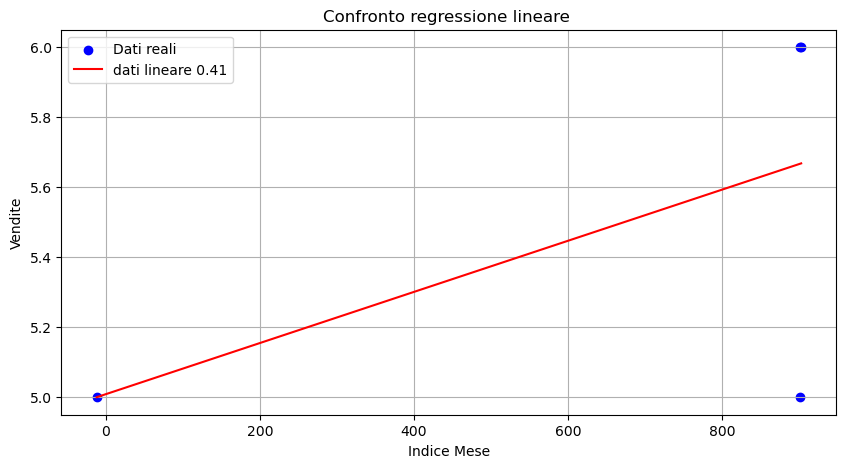

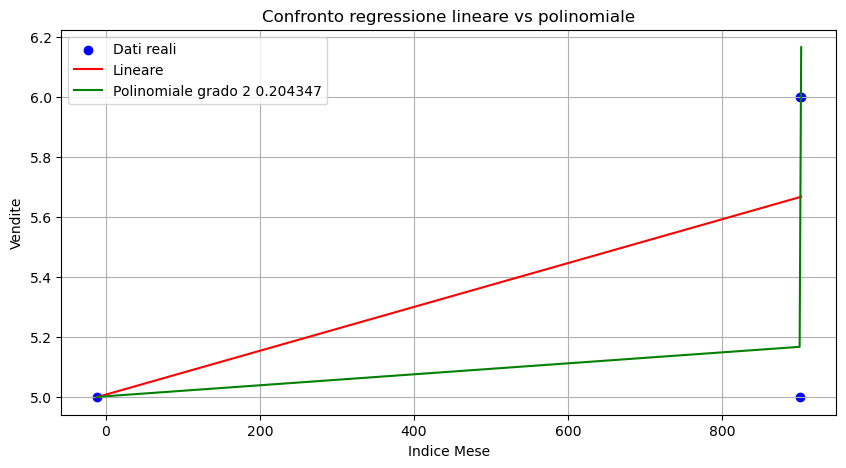

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#1 carica dataset
df = pd.read_csv("data.csv")

df.head()
print(len(df))
#2 convertili in un formato numerico

df["mese_numerico"] = range(len(df))
print(df)



# X (maiuscola) per rappresentare la matrice delle feature (variabili indipendenti)
X = df[["mese_numerico"]].values
# y (minuscola) per rappresentare il vettore target (variabile dipendente)
y = df["passengers"].values

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
# Regressione lineare
model_linear = LinearRegression()
model_linear.fit(X, y)
y_pred_linear = model_linear.predict(X)
rmse_linear = root_mean_squared_error(y, y_pred_linear)


plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Dati reali", color="blue")
plt.plot(X, y_pred_linear,label=f"dati lineare {rmse_linear:.2f}", color="red")
plt.xlabel("Indice Mese")
plt.ylabel("Vendite")
plt.title("Confronto regressione lineare ")
plt.legend()
plt.grid(True)
plt.show()

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Applica una regressione polinomiale (grado a tua scelta) = 2

model_poly2 = make_pipeline(PolynomialFeatures(2), LinearRegression())
model_poly2.fit(X, y)
y_pred_poly2 = model_poly2.predict(X)
#Calcola l’RMSE tra i valori reali e quelli predetti.
rmse_poli = root_mean_squared_error(y, y_pred_poly2)
plt.figure(figsize=(10, 5))
plt.scatter(X, y, label="Dati reali", color="blue")
plt.plot(X, y_pred_linear, label=f"Lineare", color="red")
plt.plot(X, y_pred_poly2, label=f"Polinomiale grado 2 {rmse_poli:2f}", color="green")
plt.xlabel("Indice Mese")
plt.ylabel("Vendite")
plt.title("Confronto regressione lineare vs polinomiale")
plt.legend()
plt.grid(True)
plt.show()

#Visualizza i dati reali e la curva stimata con Plotly.
import pandas as pd
import seaborn as sns

from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plotly  # NB: attenzione: qui si sta rinominando pyplot come 'plotly'
from matplotlib import font_manager as font_manager
from datetime import datetime, timedelta
import numpy as np


import plotly.figure_factory as ff

import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(x=df["mese_numerico"], y=df["passengers"], name="Dati reali",
                         mode='markers',
                         line=dict(color="blue", width=4)))

fig.add_trace(go.Scatter(x=df["mese_numerico"], y=y_pred_linear, name="lineare Predetti",
                         mode='lines',
                         line=dict(color="red", width=4)))

fig.add_trace(go.Scatter(x=df["mese_numerico"], y=y_pred_poly2, name="polinomiale Predetti",
                         mode='lines',
                         line=dict(color="red", width=4)))

fig.update_layout(
    title="Regressione",
    xaxis_title="Mesi",
    yaxis_title="Numero passeggeri",
)

fig.show()

In [19]:

import dash                      
from dash import dcc, html      
from dash.dependencies import Input, Output
import plotly.express as px     
import pandas as pd  
import pandas as pd
import seaborn as sns
import plotly.express as px
from pandas.plotting import scatter_matrix
from matplotlib import pyplot as plotly  # NB: attenzione: qui si sta rinominando pyplot come 'plotly'
from matplotlib import font_manager as font_manager
from datetime import datetime, timedelta
import numpy as np

import plotly.graph_objects as go
import plotly.figure_factory as ff
import dash                      
from dash import dcc, html      
from dash.dependencies import Input, Output
import plotly.express as px     
import pandas as pd  
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Applica una regressione polinomiale (grado a tua scelta) = 2


# Inizializza app
app = dash.Dash(__name__)   # __name__ serve per sapere se il file è eseguito direttamente

# Layout dell'applicazione: ciò che l'utente vedrà nel browser
app.layout = html.Div([
    html.H3("Seleziona un numero"),  # Titolo

    # Slider da 1 a 10 con step 1 e valore iniziale 4
    dcc.Slider(
        id='slider-numero',        # ID del componente (serve per il callback)
        min=1,
        max=10,
        step=1,
        value=4,                   # Valore iniziale
        marks={i: str(i) for i in range(1, 11)}  # Etichette visibili sullo slider
    ),

    # Div dove verrà mostrato il risultato (es: "4² = 16")
    dcc.Graph(id='output-quadrato')
])

# Callback che collega lo slider all'output testuale
@app.callback(
    Output('output-quadrato', 'figure'),       # Dove mostrare il risultato
    Input('slider-numero', 'value')
)

def calcola_quadrato(valore):
   np.random.seed(1)
   x = np.linspace(-3, 3, 100)
   y_true = 3 * x + 5 
   y = y_true + np.random.normal(scale=1.0, size=len(x))
   
   model = make_pipeline(PolynomialFeatures(valore), LinearRegression())
   model.fit(x.reshape(-1,1), y)
   y_pred = model.predict(x.reshape(-1,1))
   #Calcola l’RMSE tra i valori reali e quelli predetti.
   rmse_poli = root_mean_squared_error(y, y_pred)
   fig = go.Figure()
   fig.add_trace(go.Scatter(x=x, y=y, name="lineare Predetti",
                         mode='markers',
                         line=dict(color="red", width=4)))
   fig.add_trace(go.Scatter(x=x, y=y_pred, name="polinomiale Predetti",
                         mode='lines',
                         line=dict(color="blue", width=4)))
   fig.update_layout(
    title="Regressione",
    xaxis_title="x",
    yaxis_title="y",
)
   return fig

if __name__ == '__main__':
    # Avvia il server sulla porta 8050, accessibile da http://127.0.0.1:8050
    app.run(debug=True)